# Agent Single-Turn — LangChain Tool Calling

Single-turn ReAct agent using LangGraph + LangChain tools, hybrid retrieval (Qdrant + BM25) and Cohere reranking.

## Imports

In [9]:
from typing import Any, Annotated, List, Union
from operator import add

import cohere

from openai import OpenAI

from pydantic import BaseModel, Field

from jinja2 import Template

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import AIMessage, ToolMessage, SystemMessage

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langsmith import traceable

from qdrant_client import QdrantClient, models

from IPython.display import Image, display
from utils.utils import display_graph

## Configuration

In [10]:
# --- Clients ---
OPENAI_CLIENT = OpenAI()
COHERE_CLIENT = cohere.Client()
QDRANT_CLIENT = QdrantClient(host="localhost", port=6333)

# --- Models & Collection ---
COLLECTION_NAME = "cm_interventions_hybrid"
EMBEDDING_MODEL = "text-embedding-3-small"
KEYWORD_MODEL   = "bm25"
RERANK_MODEL    = "rerank-v4.0-pro"
GENERATION_MODEL = "gpt-4.1-mini"


## Exploring LangChain Tool Calling

In [11]:
@tool
def dummy_tool(a: str, b: str) -> str:
    """Concatenate two strings

    Args:
        a: The first string to concatenate
        b: The second string to concatenate

    Returns:
        A string of the two strings concatenated

    """
    return f"{a} {b}"


In [12]:
llm = ChatOpenAI(model = "gpt-4.1-mini")
llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto"
)


In [13]:
response = llm_with_tools.invoke("Please use dummy tool to concat two random words")
response


AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 87, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_2050a57334', 'id': 'chatcmpl-DUGIZsuWWOhwc8XWDsa969X7FW4Xt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d8819-75ad-7053-b7c1-6c5600101ea8-0', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'sunshine', 'b': 'river'}, 'id': 'call_LvPU1jiEbO1CDjQD7OoPmlaq', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 87, 'output_tokens': 20, 'total_tokens': 107, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## State & Data Models

In [14]:
class RAGUsedContext(BaseModel):
    id: Union[int, str] = Field(description="ID of the intervention")
    machine: str = Field(description="Machine of the intervention")
    date_start: str = Field(description="Date of the intervention")
    summary: str = Field(description="Summary of the intervention")

class FinalResponse(BaseModel):
    answer: str = Field(description="Answer to the question")
    references: list[RAGUsedContext]= Field(description="List of contexts used to answer the question")


class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: Annotated[List[RAGUsedContext], add] = []

class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str


## Retrieval Tools

Hybrid retrieval (dense + BM25) from Qdrant, reranked with Cohere.

In [ ]:
@traceable(name="embed_query", run_type="embedding")
def embed_text(text: str) -> list[float]:
    response = OPENAI_CLIENT.embeddings.create(input=text, model=EMBEDDING_MODEL)
    return response.data[0].embedding


@traceable(name="data_retrieval", run_type="retriever")
def retrieve_data(query: str, top_k: int = 5) -> list[dict]:
    query_vector = embed_text(query)
    search_results = QDRANT_CLIENT.query_points(
        collection_name=COLLECTION_NAME,
        prefetch=[
            models.Prefetch(query=query_vector, using=EMBEDDING_MODEL, limit=top_k // 2),
            models.Prefetch(query=models.Document(text=query, model="qdrant/" + KEYWORD_MODEL), using=KEYWORD_MODEL, limit=top_k // 2),
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1, 1])),
        limit=top_k,
    ).points
    return [{"id": point.id, "payload": point.payload, "score": point.score} for point in search_results]


# @traceable(name="reranking", run_type="retriever")
# def rerank_results(query: str, results: list[dict], top_k: int = 5) -> list[dict]:
#     if not results:
#         return []
#     contexts = [result["payload"]["summary"] for result in results]
#     response = COHERE_CLIENT.rerank(model=RERANK_MODEL, query=query, documents=contexts, top_n=top_k)
#     return [results[res.index] for res in response.results]


@traceable(name="format_cm_context", run_type="prompt")
def format_context(results: list[dict]) -> str:
    context = ""
    for result in results:
        payload = result["payload"]
        context += (
            f"ID: {payload.get('id', 'N/A')}\n"
            f"Machine: {payload.get('machine', 'N/A')}\n"
            f"Date: {payload.get('date_start', 'N/A')}\n"
            f"Summary: {payload.get('summary', 'N/A')}\n"
            + "-" * 40 + "\n"
        )
    return context


@tool
def get_formatted_cm_context(query: str, top_n: int = 10, top_k: int = 5) -> str:
    """Retrieve documents for a query, returning formatted context.

    Performs hybrid retrieval (dense + BM25) from Qdrant and returns them as a readable string.

    Args:
        query: The search query string.
        top_n: Number of candidates to retrieve. Defaults to 10.
        top_k: Unused (kept for compatibility). Defaults to 5.

    Returns:
        A formatted string with the top-n intervention records,
        each showing ID, machine, date, and summary.
    """
    results = retrieve_data(query, top_k=top_n)
    # reranked_results = rerank_results(query, results, top_k=top_k)
    return format_context(results)


## Agent Node

In [16]:
## Module-level LLM setup — single source of truth

# All retrieval tools available to the agent
RETRIEVAL_TOOLS = [get_formatted_cm_context]

# LLM for tool-calling turns (retrieval)
_llm = ChatOpenAI(model=GENERATION_MODEL)
_llm_with_tools = _llm.bind_tools(RETRIEVAL_TOOLS, tool_choice="auto")

# LLM for structured final synthesis
_llm_structured = _llm.with_structured_output(FinalResponse)

# LLM for intent routing
_llm_intent = _llm.with_structured_output(IntentRouterResponse)

In [17]:
def tool_router(state: State) -> str:
    if state.final_answer:
        return "end"
    if state.iteration > 2:
        return "end"
    last_message = state.messages[-1]
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "tools"
    return "end"

In [ ]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def agent_node(state: State) -> dict:

    prompt = """You are a maintenance assistant that can answer questions about past interventions, like possible root causes and actions for a given symptom.

## Instructions

- Use the available tools to retrieve relevant past maintenance intervention records before answering.
- Always call a tool in the first interaction to ground your answer in real maintenance history.
- If the question contains multiple distinct symptoms or topics, make separate tool calls for each one to maximize retrieval coverage.
- NEVER say what you are about to do. Act immediately.
- If this is the first message, you MUST call a retrieval tool. An answer without tool_calls on turn 1 is invalid.
- Do NOT write sentences like "I will retrieve..." or "Let me look up...". Just call the tool.
- After receiving the tool result, synthesize a clear answer for the technician.
- If the context does not contain relevant records, say so explicitly.
- Cite intervention IDs inline in the answer text using parentheses, e.g. (INT-2023-0907), every time you refer to a specific record.
- End the answer with a "References:" section listing each cited ID on its own line.
- Populate the `references` field with all cited interventions.
"""

    system_message = SystemMessage(content=prompt)
    messages = state.messages

    has_tool_results = any(isinstance(m, ToolMessage) for m in messages)
    last_message = messages[-1] if messages else None
    last_has_pending_tool_calls = last_message is not None and hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0

    if has_tool_results and not last_has_pending_tool_calls:
        response: FinalResponse = _llm_structured.invoke([system_message, *messages])
        return {
            "messages": [],
            "iteration": state.iteration + 1,
            "answer": response.answer,
            "final_answer": True,
            "references": response.references,
        }
    else:
        response = _llm_with_tools.invoke([system_message, *messages])
        return {
            "messages": [response],
            "iteration": state.iteration + 1,
            "answer": "",
            "final_answer": False,
            "references": [],
        }


## Intent Router

Routes the user question to the agent or directly to END if irrelevant to maintenance.

In [19]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a maintenance assistant that answers questions about equipment interventions and failure history.

    ## Instructions

    - Determine whether the question is about machines characteristics, components, failures, maintenance interventions or troubleshooting.
    - Questions about fault codes, symptoms, repair history, root causes, scheduled maintenance, and component replacements are relevant.
    - Questions about HR policies, personal advice, or unrelated topics are not relevant.

    ## Examples

    Question: "What caused the hydraulic pump failure on HX-350?"
    Relevant: yes

    Question: "What's the weather like today?"
    Relevant: no - not related to maintenance

    Question: "Can you help me write an email?"
    Relevant: no - not related to maintenance

    Question: "Show me all bearing failures on CB-200 last year"
    Relevant: yes

    Question: "What's the company vacation policy?"
    Relevant: no - about HR policy, not equipment maintenance

    """

    response: IntentRouterResponse = _llm_intent.invoke([
        SystemMessage(content=prompt_template),
        *state.messages
    ])

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [20]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

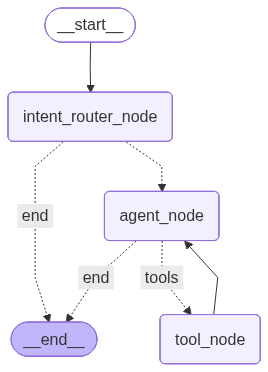

In [21]:
workflow = StateGraph(State)

tools = [get_formatted_cm_context]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("intent_router_node", intent_router_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

# Turns into React
workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()
display_graph(graph)

## Run

In [22]:
initial_state = {
    "messages": [{"role": "user", "content": "The CB-200 conveyor is showing a belt misalignment alarm and the operator also reports audible grinding noise from the rollers. What are the likely root causes and what steps should the technician follow?"}],
}

In [23]:
result = graph.invoke(initial_state)

In [24]:
result

{'messages': [{'role': 'user',
   'content': 'The CB-200 conveyor is showing a belt misalignment alarm and the operator also reports audible grinding noise from the rollers. What are the likely root causes and what steps should the technician follow?'},
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 433, 'total_tokens': 469, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_7cbb3b419a', 'id': 'chatcmpl-DUGIdcDklaj3U6dnfBCNL3mWow9HN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d8819-85ca-7cc3-beb5-f0453a899dce-0', tool_calls=[{'name': 'get_formatted_cm_context', 'args': {'query': 'CB-200 conveyor belt m

In [25]:
print(result['answer'])


The likely root causes for the belt misalignment alarm and grinding noise in the CB-200 conveyor are roller bearing failures, specifically at roller #142, which have previously been linked to drive belt elongation beyond the tensioner adjustment range. This causes elevated vibration and audible grinding noise (INT-2023-0070, INT-2025-0036).

The recommended technician steps are:
1. Inspect the roller bearings, particularly roller #142, for wear or failure.
2. Check the drive belt tension and look for elongation or wear exceeding the adjustment range of the tensioner.
3. Replace any faulty roller bearings as necessary.
4. Clean and recalibrate the components, including rollers and belt tensioners.
5. After repairs, monitor vibration levels closely to ensure machine operates within normal parameters.
6. Consider increasing inspection and monitoring frequency for early detection of reoccurrence.

These steps are supported by the past intervention records where similar symptoms were resolv